# Caso 5 — Comparação entre Modelo Vetorial e BM25

Usamos os resultados persistidos no Caso 4 (mesmos rankings, mesmas
métricas) para comparar os dois modelos de forma agregada e, principalmente,
**por consulta**. O objetivo deste caso não é apenas dizer qual modelo tem
a média maior, mas entender *onde* e *por que* eles divergem.


In [ ]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")
doc_tokens = preprocessed["stopwords_stemming"]["docs"]
query_tokens_list = preprocessed["stopwords_stemming"]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()
doc_title = dict(zip(df_docs.doc_id, df_docs.title.str.replace("\n", " ")))
query_text = dict(zip(df_queries.query_id, df_queries.text.str.replace("\n", " ")))

RESULTS_DIR = project_root / "data" / "processed"
vsm_eval = pd.read_csv(RESULTS_DIR / "vsm_perquery.csv", dtype={"query_id": str}).set_index("query_id")
bm25_eval = pd.read_csv(RESULTS_DIR / "bm25_perquery.csv", dtype={"query_id": str}).set_index("query_id")
with open(RESULTS_DIR / "vsm_rankings.pkl", "rb") as f:
    vsm_rankings = pickle.load(f)
with open(RESULTS_DIR / "bm25_rankings.pkl", "rb") as f:
    bm25_rankings = pickle.load(f)

## Comparação agregada

O resultado agregado é misto, não uma vitória uniforme de um modelo. O
BM25 tem MAP, NDCG@10 e MRR ligeiramente maiores (MAP 0,2956 contra
0,2839, NDCG@10 0,3350 contra 0,3293 e MRR praticamente empatado, 0,5310
contra 0,5292). Já o Modelo Vetorial tem Precision@10, Recall@10 e
F1@10 ligeiramente maiores (P@10 0,2222 contra 0,2169 e Recall@10
0,3735 contra 0,3670). Ou seja, o BM25 tende a ordenar melhor os
documentos relevantes que aparecem, em métricas sensíveis à posição
como MAP e NDCG, enquanto o Modelo Vetorial recupera, em média, uma
fração ligeiramente maior de documentos relevantes dentro do Top 10,
em métricas de conjunto como Precision@10 e Recall@10. Em qualquer
direção, as diferenças agregadas são pequenas, abaixo de 5% relativos
na maioria das métricas.


In [ ]:
agg = pd.DataFrame({
    "Modelo Vetorial": vsm_eval.drop(columns="n_relevant").mean(),
    "BM25": bm25_eval.drop(columns="n_relevant").mean(),
})
agg["BM25 - Vetorial"] = agg["BM25"] - agg["Modelo Vetorial"]
display(agg.round(4))

n_wins_bm25 = (bm25_eval["AP"] > vsm_eval["AP"]).sum()
n_wins_vsm = (vsm_eval["AP"] > bm25_eval["AP"]).sum()
n_ties = (bm25_eval["AP"] == vsm_eval["AP"]).sum()
print(f"\nPor consulta (AP): BM25 melhor em {n_wins_bm25}, Modelo Vetorial melhor em {n_wins_vsm}, "
      f"empate em {n_ties} (de {len(vsm_eval)} consultas)")

,Modelo Vetorial,BM25,BM25 - Vetorial
precision@10,0.2222,0.2169,-0.0053
recall@10,0.3735,0.3670,-0.0065
AP,0.2839,0.2956,0.0117
F1@10,0.2513,0.2460,-0.0053
MRR,0.5292,0.5310,0.0018
ndcg@10,0.3293,0.3350,0.0056



Por consulta (AP): BM25 melhor em 110, Modelo Vetorial melhor em 106, empate em 9 (de 225 consultas)


## Divergência por consulta

A média agregada esconde uma heterogeneidade grande. Olhando consulta a
consulta, o BM25 tem AP maior em 110 das 225 consultas, o Modelo Vetorial
vence em 106 e há 9 empates, um cenário quase equilibrado. Isso já
indica que a pequena vantagem agregada do BM25 em MAP não vem de vencer
quase sempre por pouco, mas de vencer com folga em parte das consultas,
enquanto perde, também com folga, em outra parte de tamanho comparável.


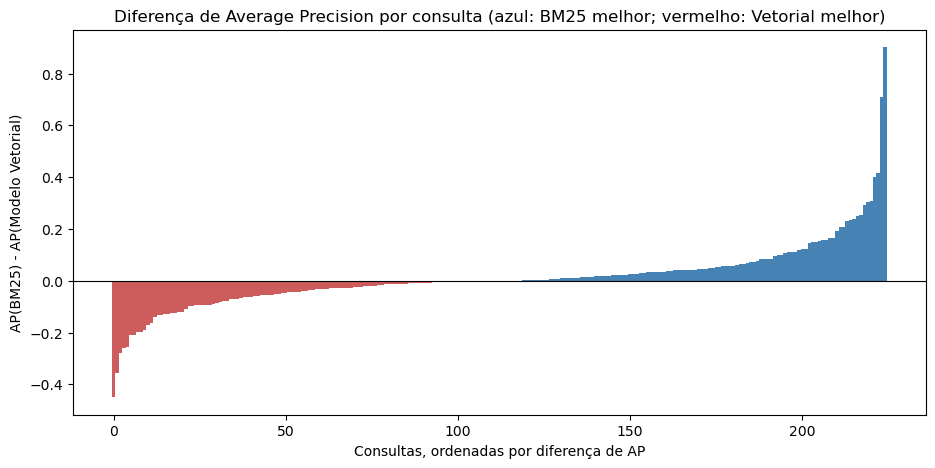

In [ ]:
diff = (bm25_eval["AP"] - vsm_eval["AP"]).sort_values()
plt.figure(figsize=(11, 5))
colors = ["indianred" if v < 0 else "steelblue" for v in diff.values]
plt.bar(range(len(diff)), diff.values, color=colors, width=1.0)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Consultas, ordenadas por diferença de AP")
plt.ylabel("AP(BM25) - AP(Modelo Vetorial)")
plt.title("Diferença de Average Precision por consulta (azul: BM25 melhor; vermelho: Vetorial melhor)")
plt.show()

## Consultas com maiores diferenças

In [ ]:
print("Consultas onde BM25 mais supera o Modelo Vetorial (maior diferença de AP):")
top_bm25 = diff.sort_values(ascending=False).head(5)
display(pd.DataFrame({
    "query": [query_text[q] for q in top_bm25.index],
    "AP_BM25": bm25_eval.loc[top_bm25.index, "AP"].round(3),
    "AP_Vetorial": vsm_eval.loc[top_bm25.index, "AP"].round(3),
    "diferenca": top_bm25.round(3),
}))

print("\nConsultas onde o Modelo Vetorial mais supera o BM25 (maior diferença negativa de AP):")
top_vsm = diff.sort_values().head(5)
display(pd.DataFrame({
    "query": [query_text[q] for q in top_vsm.index],
    "AP_BM25": bm25_eval.loc[top_vsm.index, "AP"].round(3),
    "AP_Vetorial": vsm_eval.loc[top_vsm.index, "AP"].round(3),
    "diferenca": top_vsm.round(3),
}))

Consultas onde BM25 mais supera o Modelo Vetorial (maior diferença de AP):


,query,AP_BM25,AP_Vetorial,diferenca
query_id,,,,
167,exact solution methods for calculating the abl...,1.000,0.098,0.902
81,what are wind-tunnel corrections for a two-dim...,1.000,0.292,0.708
173,references on lyapunov's method on the stabili...,1.000,0.583,0.417
36,has anyone investigated relaxation effects on ...,0.503,0.102,0.401
118,what are the aerodynamic interference effects ...,0.566,0.259,0.307



Consultas onde o Modelo Vetorial mais supera o BM25 (maior diferença negativa de AP):


,query,AP_BM25,AP_Vetorial,diferenca
query_id,,,,
77,how close is the comparison of the shock layer...,0.297,0.746,-0.450
145,what are the best experimental data and classi...,0.197,0.554,-0.357
178,has a criterion been established for determini...,0.268,0.546,-0.277
191,"what is the criterion for true panel flutter, ...",0.391,0.652,-0.261
21,why does the compressibility transformation fa...,0.069,0.324,-0.256


### Por que o BM25 vence com folga na consulta 167?

A consulta pede métodos para calcular perda de massa por ablação em voo
hipersônico. O Modelo Vetorial coloca em primeiro lugar o documento 553,
não julgado, que repete o termo `ablat` 7 vezes em apenas 98 tokens. O
BM25 prefere corretamente o documento 274, relevante de grau 2, que
cobre muito mais termos distintos da consulta (`ablat`, `method`,
`materi`, `exact`, `solut`, `mass`, `temperatur`, `loss`, `calcul`),
ainda que repita `ablat` só 2 vezes.

Isso ilustra o papel da saturação de frequência de termo do BM25. A
fórmula `f*(k1+1)/(f+k1*norm)` cresce rapidamente nas primeiras
ocorrências de um termo, mas se achata nas seguintes, de modo que ir de
1 para 7 ocorrências está longe de multiplicar o score por 7. Já o peso
logarítmico do Modelo Vetorial (`1 + log10(f)`), combinado com a
normalização em L2 de um documento curto, onde poucos termos competem
pela mesma norma, permite que a repetição concentrada de um único termo
raro domine o vetor do documento 553 e infle sua similaridade de cosseno
com a consulta. Em outras palavras, o BM25 resiste melhor à repetição
isolada de um termo e favorece documentos que cobrem mais aspectos da
consulta.


In [ ]:
# Estudo de caso: consulta 167 (BM25 >> Modelo Vetorial)
q = "167"
print(f"Consulta {q}: {query_text[q]}")
print(f"Tokens: {query_tokens_list[query_ids.index(q)]}\n")

grades = dict(zip(df_qrels[df_qrels.query_id == q].doc_id, df_qrels[df_qrels.query_id == q].relevance))
for did in ["553", "274"]:
    idx = doc_ids.index(did)
    toks = doc_tokens[idx]
    from collections import Counter
    counts = Counter(toks)
    q_toks = set(query_tokens_list[query_ids.index(q)])
    overlap = {t: counts[t] for t in q_toks if counts[t] > 0}
    print(f"doc {did} (grau={grades.get(did, 'não julgado')}, {len(toks)} tokens): "
          f"sobreposição com a consulta = {overlap}")

Consulta 167: exact solution methods for calculating the ablative mass loss of a material ablating at high temperatures in a hypersonic flight environment .
Tokens: ['exact', 'solut', 'method', 'calcul', 'abl', 'mass', 'loss', 'materi', 'ablat', 'high', 'temperatur', 'hyperson', 'flight', 'environ']

doc 553 (grau=não julgado, 100 tokens): sobreposição com a consulta = {'ablat': 8, 'materi': 5, 'mass': 1, 'solut': 3, 'hyperson': 1, 'flight': 1}
doc 274 (grau=2, 139 tokens): sobreposição com a consulta = {'ablat': 2, 'calcul': 1, 'method': 2, 'materi': 1, 'mass': 3, 'solut': 2, 'exact': 1, 'temperatur': 2, 'loss': 1}


### Por que o Modelo Vetorial vence com folga na consulta 113?

Aqui o padrão se inverte. A consulta pede dados sobre forças
aerodinâmicas oscilatórias em superfícies de controle a números de Mach
transônicos. O BM25 privilegia o documento 815, não julgado, que tem
alta frequência de termos genéricos e de idf baixo da área (`mach` 4
vezes, `number` 5 vezes, `aerodynam` 3 vezes, termos que aparecem em
centenas de resumos da coleção). O Modelo Vetorial, por sua vez,
encontra logo no topo o documento 265, relevante de grau 3, um documento
curto de 49 tokens cuja sobreposição com a consulta é pequena em
quantidade de termos (`control`, `surfac`, `oscillatori`), mas
concentrada em termos mais raros e específicos, sendo que `oscillatori`
sozinho tem um dos maiores idf da coleção.

O BM25 soma contribuições ao longo de vários termos da consulta, mesmo
os de idf baixo, desde que apareçam com frequência razoável, o que
permite que um documento mais longo, cobrindo superficialmente muitos
termos comuns, acumule um score competitivo. Já o cosseno do Modelo
Vetorial depende da direção do vetor, de modo que um documento curto,
dominado por poucos termos de alto idf que coincidem com a consulta,
produz um vetor quase paralelo ao da consulta, mesmo sem tocar em todos
os termos genéricos dela. Este é o padrão inverso do observado na
consulta 167.


In [ ]:
# Estudo de caso: consulta 113 (Modelo Vetorial >> BM25)
q = "113"
print(f"Consulta {q}: {query_text[q]}")
print(f"Tokens: {query_tokens_list[query_ids.index(q)]}\n")

grades = dict(zip(df_qrels[df_qrels.query_id == q].doc_id, df_qrels[df_qrels.query_id == q].relevance))
for did in ["815", "265"]:
    idx = doc_ids.index(did)
    toks = doc_tokens[idx]
    from collections import Counter
    counts = Counter(toks)
    q_toks = set(query_tokens_list[query_ids.index(q)])
    overlap = {t: counts[t] for t in q_toks if counts[t] > 0}
    print(f"doc {did} (grau={grades.get(did, 'não julgado')}, {len(toks)} tokens): "
          f"sobreposição com a consulta = {overlap}")

Consulta 113: what data exists on oscillatory aerodynamic forces on control surfaces at transonic mach numbers .
Tokens: ['data', 'exist', 'oscillatori', 'aerodynam', 'forc', 'control', 'surfac', 'transon', 'mach', 'number']

doc 815 (grau=não julgado, 147 tokens): sobreposição com a consulta = {'transon': 2, 'oscillatori': 2, 'mach': 4, 'number': 5, 'aerodynam': 4}
doc 265 (grau=3, 49 tokens): sobreposição com a consulta = {'oscillatori': 1, 'control': 2, 'surfac': 2}


### Síntese

As duas consultas de estudo de caso mostram que a diferença entre os
modelos não é aleatória. Ela nasce de dois mecanismos conhecidos e
opostos.

1. Saturação de frequência no BM25. Penaliza documentos que inflam sua
   relevância aparente repetindo excessivamente um único termo e
   favorece cobertura de múltiplos aspectos da consulta. Favorece o
   BM25 quando o documento relevante é mais completo e o distrator é
   repetitivo, como na consulta 167.
2. Concentração vetorial no Modelo Vetorial. Favorece documentos curtos
   e muito focados em poucos termos raros ou específicos compartilhados
   com a consulta, mesmo quando não cobrem termos genéricos dela.
   Favorece o Vetorial quando o documento relevante é curto e
   específico, e o distrator do BM25 é longo e genérico, como na
   consulta 113.

Nenhum dos dois mecanismos é certo ou errado em geral. Cada um ajuda em
alguns cenários e atrapalha em outros, o que explica por que a diferença
agregada entre os modelos é pequena apesar de, consulta a consulta, as
diferenças individuais serem grandes e sistemáticas.